In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

C:\Users\Hridik\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
df = pd.read_csv(r'C:\Users\Hridik\Desktop\archive\department_store_dataset.csv')

In [6]:
df.shape

(41629, 9)

# Data Cleaning

In [7]:
df.head()

,Seller,Department,Revenue,Revenue Goal,Margin,Margin Goal,Date,Sales Quantity,Customers
0,Letícia Nascimento,Eletrônicos,6139.41,1857.66,0.14,0.18,2017-01-01,50,213
1,Ana Sousa,Eletrônicos,7044.96,5236.01,0.30,0.17,2017-01-01,52,256
2,Gustavo Martins,Eletrônicos,4109.85,1882.47,0.14,0.20,2017-01-01,33,189
3,Beatriz Santos,Vestuário,315.30,2069.08,0.20,0.17,2017-01-01,2,6
4,Camila Lima,Vestuário,1672.33,3587.07,0.24,0.14,2017-01-01,12,50


In [8]:
df.describe()

,Revenue,Revenue Goal,Margin,Margin Goal,Sales Quantity,Customers
count,41629.000000,41629.000000,41629.000000,41629.000000,41629.000000,41629.000000
mean,4304.522655,4458.557065,0.279164,0.291039,33.368950,126.298878
std,4158.522015,3258.360518,0.150589,0.113495,30.885202,123.439971
min,0.000000,241.010000,0.028000,0.140000,0.000000,0.000000
25%,1239.000000,1980.560000,0.170000,0.200000,10.000000,36.000000
50%,2934.710000,3472.410000,0.250000,0.260000,24.000000,89.000000
75%,6110.730000,6269.260000,0.350000,0.360000,47.000000,179.000000
max,22471.310000,16987.970000,0.800000,0.600000,185.000000,859.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41629 entries, 0 to 41628
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Seller          41629 non-null  object 
 1   Department      41629 non-null  object 
 2   Revenue         41629 non-null  float64
 3   Revenue Goal    41629 non-null  float64
 4   Margin          41629 non-null  float64
 5   Margin Goal     41629 non-null  float64
 6   Date            41629 non-null  object 
 7   Sales Quantity  41629 non-null  int64  
 8   Customers       41629 non-null  int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 2.9+ MB


In [10]:
df['Date'] = pd.to_datetime(df['Date'], errors = 'coerce')

In [11]:
df.head()

,Seller,Department,Revenue,Revenue Goal,Margin,Margin Goal,Date,Sales Quantity,Customers
0,Letícia Nascimento,Eletrônicos,6139.41,1857.66,0.14,0.18,2017-01-01,50,213
1,Ana Sousa,Eletrônicos,7044.96,5236.01,0.30,0.17,2017-01-01,52,256
2,Gustavo Martins,Eletrônicos,4109.85,1882.47,0.14,0.20,2017-01-01,33,189
3,Beatriz Santos,Vestuário,315.30,2069.08,0.20,0.17,2017-01-01,2,6
4,Camila Lima,Vestuário,1672.33,3587.07,0.24,0.14,2017-01-01,12,50


In [12]:
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

# Checking Missing values

In [13]:
df.isna()

,Seller,Department,Revenue,Revenue Goal,Margin,Margin Goal,Date,Sales Quantity,Customers,Month,DayOfWeek,Quarter
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
41624,False,False,False,False,False,False,False,False,False,False,False,False
41625,False,False,False,False,False,False,False,False,False,False,False,False
41626,False,False,False,False,False,False,False,False,False,False,False,False
41627,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df.duplicated().sum()

0

In [15]:
df['Revenue'].median()

2934.71

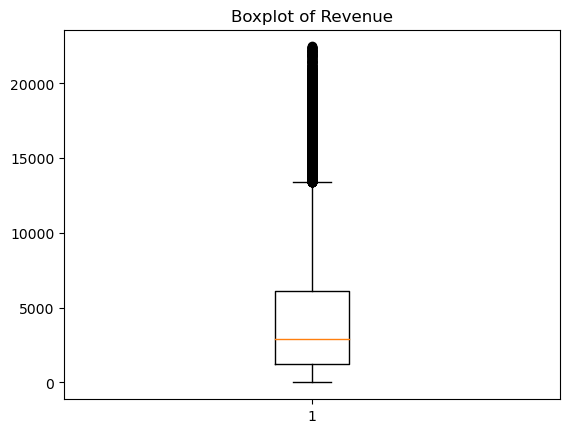

In [16]:
plt.boxplot(df['Revenue'])
plt.title('Boxplot of Revenue')
plt.show()

# The Data has some really high values which suggest bulk purchases or seasonal spikes

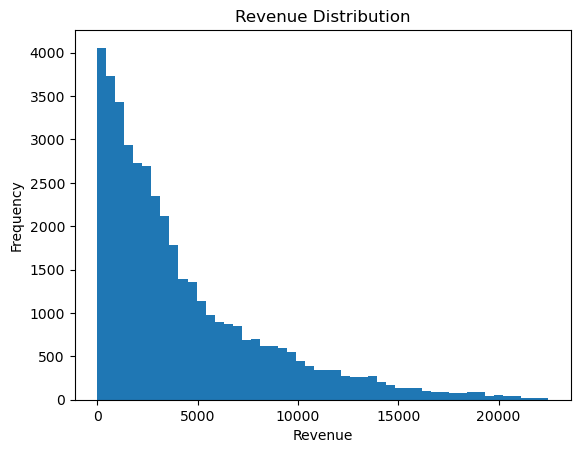

In [17]:
plt.hist(df['Revenue'], bins = 50)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

The Data is skewed more towards Left 

In [18]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]
outliers.shape

(1954, 12)

1954 means that many results have outliers and are skewed right

In [19]:
outlier_pct = outliers.shape[0] / df.shape[0] * 100
outlier_pct


4.693843234283793

In [20]:
outliers['Revenue'].describe()

count     1954.000000
mean     16355.059555
std       2348.014100
min      13420.560000
25%      14296.532500
50%      15780.265000
75%      18149.300000
max      22471.310000
Name: Revenue, dtype: float64

In [21]:
df['Revenue'].describe()

count    41629.000000
mean      4304.522655
std       4158.522015
min          0.000000
25%       1239.000000
50%       2934.710000
75%       6110.730000
max      22471.310000
Name: Revenue, dtype: float64

Although the IQR method identified ~4.7% of transactions as outliers, these values represent legitimate high-revenue sales rather than data errors. Therefore, all observations were retained. To address the strong right-skewness of the target variable, a log transformation was applied before modeling.

# EDA

In [22]:
df['log_Revenue'] = np.log1p(df['Revenue'])

In [23]:
df.head()

,Seller,Department,Revenue,Revenue Goal,Margin,Margin Goal,Date,Sales Quantity,Customers,Month,DayOfWeek,Quarter,log_Revenue
0,Letícia Nascimento,Eletrônicos,6139.41,1857.66,0.14,0.18,2017-01-01,50,213,1,6,1,8.722647
1,Ana Sousa,Eletrônicos,7044.96,5236.01,0.30,0.17,2017-01-01,52,256,1,6,1,8.860210
2,Gustavo Martins,Eletrônicos,4109.85,1882.47,0.14,0.20,2017-01-01,33,189,1,6,1,8.321385
3,Beatriz Santos,Vestuário,315.30,2069.08,0.20,0.17,2017-01-01,2,6,1,6,1,5.756691
4,Camila Lima,Vestuário,1672.33,3587.07,0.24,0.14,2017-01-01,12,50,1,6,1,7.422571


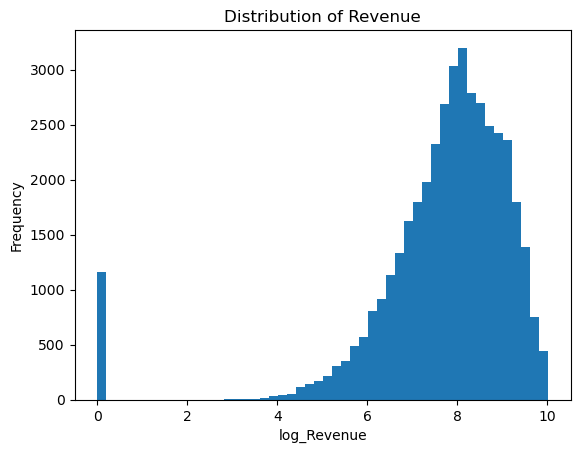

In [24]:
plt.hist(df['log_Revenue'], bins=50)
plt.title('Distribution of Revenue')
plt.xlabel('log_Revenue')
plt.ylabel('Frequency')
plt.show()

The raw revenue distribution is heavily right-skewed. Applying a log transformation using log1p reduces skewness and produces a more symmetric distribution, making the target variable more suitable for linear regression modeling

In [25]:
Q1 = df['log_Revenue'].quantile(0.25)
Q3 = df['log_Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = df[(df['log_Revenue'] < lower_bound) | (df['log_Revenue'] > upper_bound)]
outliers.shape

(1517, 13)

After applying a log transformation to the revenue, approximately 3.6% of observations were flagged as statistical outliers using the IQR method. These data points were retained, as they represent valid high-revenue transactions and are relevant for real-world predictive performance

# Splitting and Pipeline

In [26]:
X = df.drop(columns = ['Revenue','log_Revenue','Date'])
y = df['log_Revenue']

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

The above train test split makes sure that data leakage is minimal

In [28]:
num_features = X_train.select_dtypes(include = ['int64','float64']).columns
cat_features = X_train.select_dtypes(include = ['object']).columns

Building a preprocessing pipeline

In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
                transformers = [
                    ('num',StandardScaler(),num_features),
                    ('cat',OneHotEncoder(handle_unknown='ignore'), cat_features)
                ])

Building Transformers

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linreg = Pipeline(steps =[
    ('preprocess',preprocessor),
    ('model',LinearRegression())
])
linreg.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Revenue Goal', 'Margin', 'Margin Goal', 'Sales Quantity', 'Customers'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Seller', 'Department'], dtype='object'))])),
                ('model', LinearRegression())])

Base Line Linear Regression

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = linreg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = np.sqrt(mean_squared_error(y_test,y_pred))

print(mae,mse)

0.7197901946818364 1.2935178339670834


In [32]:
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae, baseline_rmse

(1.1226435525089282, 1.716656350746361)

In [33]:
from sklearn.model_selection import cross_val_score

cv_mae = -cross_val_score(
linreg, 
X_train,
y_train,
scoring = 'neg_mean_absolute_error',
    cv = 5)

cv_mae.mean(),cv_mae.std()

(0.7219126991718581, 0.007022256550143341)

cross validated mae 

In [34]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_mse = -cross_val_score(
    linreg,
    X_train,
    y_train,
    scoring='neg_mean_squared_error',
    cv=5
)

cv_rmse = np.sqrt(cv_mse)

cv_rmse.mean(), cv_rmse.std()


(1.283293688746467, 0.020825770709283382)

cross validated mse

A baseline linear regression model was trained using a full preprocessing pipeline. The model achieved a cross-validated MAE of 0.72 ± 0.01 and RMSE of 1.28 ± 0.02 on a log-transformed revenue target, demonstrating stable and reliable performance.

# Ridge and Lasso Regression

In [35]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3,3,20)

In [36]:
ridge = Pipeline(steps = [
    ('preprocess',preprocessor),
    ('model',RidgeCV(alphas= alphas, cv=5))
])

Pipeline for Ridge

In [37]:
ridge.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Revenue Goal', 'Margin', 'Margin Goal', 'Sales Quantity', 'Customers'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Seller', 'Department'], dtype='object'))])),
                ('model',
                 RidgeCV(alphas=array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
       1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
       3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
       6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
       1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03]),
                         cv=5))])

fitting the ridge regression

In [38]:
ridge.named_steps['model'].alpha_

112.88378916846884

In [39]:
y_pred_ridge = ridge.predict(X_test)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test,y_pred_ridge))
ridge_mae,ridge_rmse

(0.7190340322690941, 1.2936111553080052)

In [40]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
lasso = Pipeline(steps = [
    ('preprocess', preprocessor),
    ('model',LassoCV(alphas = np.logspace(-3,3,50),
                    cv = 5, 
                    max_iter = 100000,
                    random_state = 42))
])
lasso.fit(X_train,y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Revenue Goal', 'Margin', 'Margin Goal', 'Sales Quantity', 'Customers'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Seller', 'Department'], dtype='object'))])),
                ('model',
                 LassoCV(alphas=array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.3...
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03]),
                         cv=5, max_iter=100000, random_state=42))])

In [41]:
lasso_alpha = lasso.named_steps['model'].alpha_
lasso_alpha

0.0017575106248547913

In [42]:
feature_names = preprocessor.get_feature_names_out()
coeffs = lasso.named_steps['model'].coef_
selected_features = feature_names[coeffs != 0]
len(selected_features),selected_features[:10]

(9,
 array(['num__Revenue Goal', 'num__Margin', 'num__Margin Goal',
        'num__Sales Quantity', 'num__Customers',
        'cat__Department_Brinquedo', 'cat__Department_Casa',
        'cat__Department_Papelaria', 'cat__Department_Vestuário'],
       dtype=object))

In [43]:
y_pred_lasso = lasso.predict(X_test)
lasso_mae = mean_absolute_error(y_test,y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test,y_pred_lasso))
lasso_mae,lasso_rmse

(0.719178269977252, 1.293777219743533)

Doing a Mae and RMSE for Lasso Regression

In [44]:
feature_names = preprocessor.get_feature_names_out()
coeff = ridge.named_steps['model'].coef_

coef_df = (
 pd.DataFrame({
     "Feature":feature_names, 
     "Coefficient":coeffs
 })
     .sort_values(by = "Coefficient",ascending = False)
)
coef_df.head(10),coef_df.tail(10)

(                           Feature  Coefficient
 3              num__Sales Quantity     1.183439
 25       cat__Department_Brinquedo     0.091293
 30       cat__Department_Vestuário     0.074371
 16  cat__Seller_Letícia Nascimento    -0.000000
 28        cat__Department_Esportes    -0.000000
 27     cat__Department_Eletrônicos    -0.000000
 24      cat__Department_Acessórios     0.000000
 23     cat__Seller_Vitória Ribeiro     0.000000
 22     cat__Seller_Thiago Carvalho     0.000000
 21      cat__Seller_Thiago Barbosa     0.000000,
                         Feature  Coefficient
 8       cat__Seller_Camila Lima     0.000000
 7   cat__Seller_Camila Carvalho    -0.000000
 6    cat__Seller_Beatriz Santos     0.000000
 5         cat__Seller_Ana Sousa    -0.000000
 2              num__Margin Goal    -0.011215
 1                   num__Margin    -0.033829
 26         cat__Department_Casa    -0.065279
 4                num__Customers    -0.074946
 0             num__Revenue Goal    -0.084846


According to Coefficient we can see that higher revenue goal & customer count doesn't neccessarily mean higher realized revenue, highlighting potential operational inefficiencies

Given the mdoels we have trained now Ridge Regression gives us the best fit even though the mae and rmse is similar since ridge alpha gives strong coefficient stabilization

# Final Model 

In [45]:
final_model = ridge
final_model.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Revenue Goal', 'Margin', 'Margin Goal', 'Sales Quantity', 'Customers'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Seller', 'Department'], dtype='object'))])),
                ('model',
                 RidgeCV(alphas=array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
       1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
       3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
       6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
       1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03]),
                         cv=5))])

In [46]:
new_data = pd.DataFrame([{
    "Sales Quantity": 45,
    "Customers": 120,
    "Margin": 0.28,
    "Margin Goal": 0.30,
    "Revenue Goal": 6000,
    "Date": "2025-01-15",
    "Department": "Brinquedo",
    "Seller": "Ana Sousa"
}])


In [47]:
def predict_revenue(raw_input_df):
    df = raw_input_df.copy()

    # 1️⃣ Validate input ranges
    limits = {
        "Revenue Goal": (241, 16988),
        "Sales Quantity": (0, 185),
        "Customers": (0, 859),
        "Margin": (0.028, 0.8),
        "Margin Goal": (0.14, 0.6)
    }

    for col, (low, high) in limits.items():
        if not (low <= df[col].iloc[0] <= high):
            raise ValueError(
                f"{col}={df[col].iloc[0]} outside training range [{low}, {high}]"
            )

    # 2️⃣ Feature engineering
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Quarter'] = df['Date'].dt.quarter
    df = df.drop(columns=['Date'])

    # 3️⃣ Predict
    log_pred = final_model.predict(df)
    return np.expm1(log_pred)


In [48]:
revenue_pred = predict_revenue(new_data)


In [49]:
revenue_pred

array([3382.28203727])

In [50]:
feature_ranges = {
    "Sales Quantity": {
        "min": X_train["Sales Quantity"].min(),
        "max": X_train["Sales Quantity"].max()
    },
    "Customers": {
        "min": X_train["Customers"].min(),
        "max": X_train["Customers"].max()
    },
    "Margin": {
        "min": X_train["Margin"].min(),
        "max": X_train["Margin"].max()
    },
    "Margin Goal": {
        "min": X_train["Margin Goal"].min(),
        "max": X_train["Margin Goal"].max()
    },
    "Revenue Goal": {
        "min": X_train["Revenue Goal"].min(),
        "max": X_train["Revenue Goal"].max()
    }
}


In [51]:
import os
import joblib

base_path = r"C:\Users\Hridik\Desktop\Python\Machine Learning\Projects"
model_path = os.path.join(base_path, "model")

os.makedirs(model_path, exist_ok=True)

joblib.dump(final_model, os.path.join(model_path, "final_model.pkl"))

['C:\\Users\\Hridik\\Desktop\\Python\\Machine Learning\\Projects\\model\\final_model.pkl']

In [52]:
feature_ranges = {
    "Sales Quantity": {
        "min": X_train["Sales Quantity"].min(),
        "max": X_train["Sales Quantity"].max()
    },
    "Customers": {
        "min": X_train["Customers"].min(),
        "max": X_train["Customers"].max()
    },
    "Margin": {
        "min": X_train["Margin"].min(),
        "max": X_train["Margin"].max()
    },
    "Margin Goal": {
        "min": X_train["Margin Goal"].min(),
        "max": X_train["Margin Goal"].max()
    },
    "Revenue Goal": {
        "min": X_train["Revenue Goal"].min(),
        "max": X_train["Revenue Goal"].max()
    }
}


In [3]:
!pip install fastapi

     ------------------------------------ 117.5/117.5 kB 857.9 kB/s eta 0:00:00
     -------------------------------------- 472.3/472.3 kB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 44.6/44.6 kB 2.3 MB/s eta 0:00:00
     ---------------------------------------- 73.3/73.3 kB ? eta 0:00:00
     ---------------------------------------- 2.1/2.1 MB 14.6 MB/s eta 0:00:00
     -------------------------------------- 114.4/114.4 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.4.0
    Uninstalling typing_extensions-4.4.0:
      Successfully uninstalled typing_extensions-4.4.0
  Attempting uninstall: anyio
    Found existing installation: anyio 3.5.0
    Uninstalling anyio-3.5.0:
      Successfully uninstalled anyio-3.5.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.8.0 requires absl-py>=0.4.0, which is not installed.
tensorflow 2.8.0 requires astunparse>=1.6.0, which is not installed.
tensorflow 2.8.0 requires flatbuffers>=1.12, which is not installed.
tensorflow 2.8.0 requires gast>=0.2.1, which is not installed.
tensorflow 2.8.0 requires google-pasta>=0.1.1, which is not installed.
tensorflow 2.8.0 requires grpcio<2.0,>=1.24.3, which is not installed.
tensorflow 2.8.0 requires keras<2.9,>=2.8.0rc0, which is not installed.
tensorflow 2.8.0 requires keras-preprocessing>=1.1.1, which is not installed.
tensorflow 2.8.0 requires libclang>=9.0.1, which is not installed.
tensorflow 2.8.0 requires opt-einsum>=2.3.2, which is not installed.
tensorflow 2.8.0 requires protobuf>=3.9.2, which is not installed.
tensorflow 2.8.0 requires tensorboard<2.9,>=2.8, which is not i